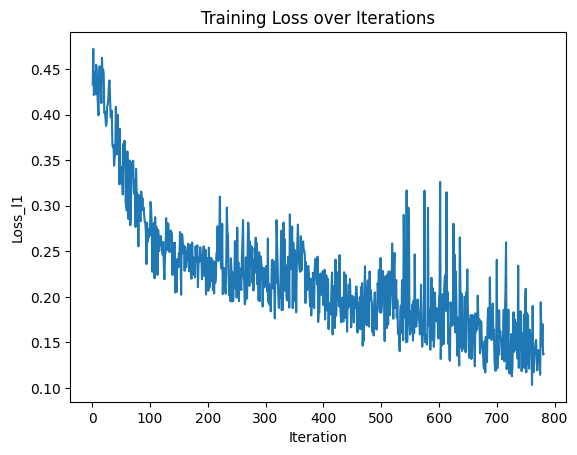

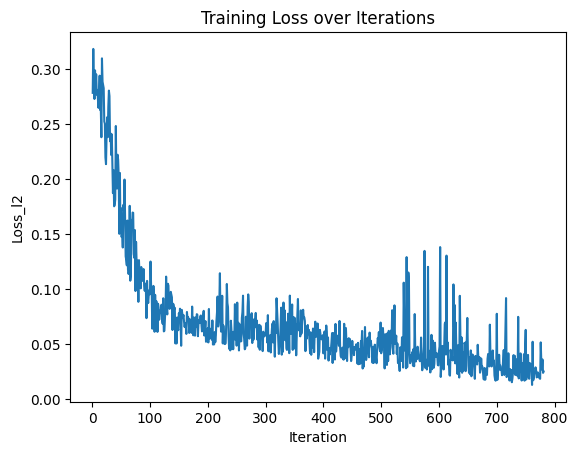

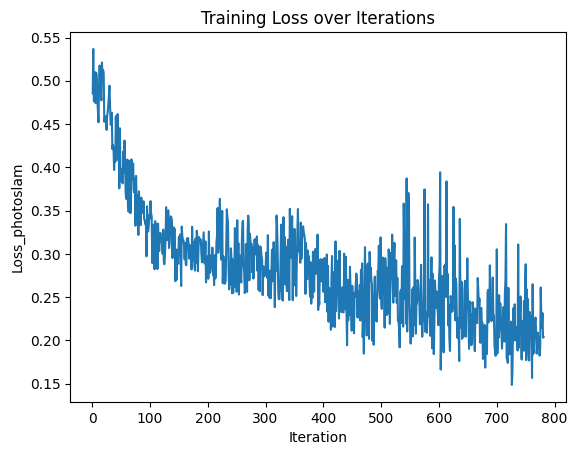

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV you just generated
df1 = pd.read_csv('/home/dimitris/Photo-SLAM/loss_l1.csv', names=['iteration', 'loss'])

plt.figure()
plt.plot(df1['iteration'], df1['loss'])
plt.xlabel('Iteration')
plt.ylabel('Loss_l1')
plt.title('Training Loss over Iterations')

plt.savefig('loss_l1_plot.png', dpi=300, bbox_inches='tight')

# Read the CSV you just generated
df2 = pd.read_csv('/home/dimitris/Photo-SLAM/loss_l2.csv', names=['iteration', 'loss'])

plt.figure()
plt.plot(df2['iteration'], df2['loss'])
plt.xlabel('Iteration')
plt.ylabel('Loss_l2')
plt.title('Training Loss over Iterations')

plt.savefig('loss_l2_plot.png', dpi=300, bbox_inches='tight')

# Read the CSV you just generated
df3 = pd.read_csv('/home/dimitris/Photo-SLAM/loss_ssim.csv', names=['iteration', 'loss'])

plt.figure()
plt.plot(df3['iteration'], df3['loss'])
plt.xlabel('Iteration')
plt.ylabel('Loss_photoslam')
plt.title('Training Loss over Iterations')

plt.savefig('loss_photoslam_plot.png', dpi=300, bbox_inches='tight')


In [2]:
import numpy as np
import open3d as o3d

# === Configuration ===
BASE     = "/home/dimitris/Photo-SLAM"
OUT_IMG  = "voxel_debug.png"

# === Load old data ===
pts       = np.load(f"{BASE}/debug_pts.npy")          # N×3
cols      = np.load(f"{BASE}/debug_cols.npy")         # N×3
centers   = np.load(f"{BASE}/debug_vox_centers.npy")  # M×3
sizes     = np.load(f"{BASE}/debug_vox_size.npy")     # M
voxcols   = np.load(f"{BASE}/debug_vox_color.npy")    # M×3

# # === Load new/incremental data ===
new_pts     = np.load(f"{BASE}/debug_new_pts.npy")           # Nnew×3
new_cols    = np.load(f"{BASE}/debug_new_cols.npy")          # Nnew×3
# new_centers = np.load(f"{BASE}/debug_new_vox_centers.npy")   # Mnew×3
# new_sizes   = np.load(f"{BASE}/debug_new_vox_size.npy")      # Mnew×1
# new_voxcols = np.load(f"{BASE}/debug_new_vox_color.npy")     # Mnew×3
# print("total new points:", new_pts.shape)

# voxel AABB from centers +/- size/2 per voxel (use global min/max) / svraster method
emin = (centers - sizes[:,None]*0.5).min(0)
emax = (centers + sizes[:,None]*0.5).max(0)
# emin = np.array([-5.558918,-10.429258,-0.166463])
# emax = np.array([26.919661,6.241067,36.555431])
print("voxel grid AABB min:", emin, "max:", emax)

def frac_outside(P):
    inside = (
        (P[:,0] >= emin[0]) & (P[:,0] <= emax[0]) &
        (P[:,1] >= emin[1]) & (P[:,1] <= emax[1]) &
        (P[:,2] >= emin[2]) & (P[:,2] <= emax[2])
    )
    return 1.0 - inside.mean()

print("Grid AABB min:", emin, "max:", emax)
print("Old pts outside fraction:", frac_outside(pts))
print("New pts outside fraction:", frac_outside(new_pts))

# === Old point‐cloud ===
pcd_old = o3d.geometry.PointCloud()
pcd_old.points = o3d.utility.Vector3dVector(pts)
pcd_old.colors = o3d.utility.Vector3dVector(cols)

# === New point‐cloud (highlight in red-ish) ===
pcd_new = o3d.geometry.PointCloud()
pcd_new.points = o3d.utility.Vector3dVector(new_pts)
# if you already have colors, you can use them; or override:
# pcd_new.colors = o3d.utility.Vector3dVector(new_cols)
pcd_new.colors = o3d.utility.Vector3dVector(
    np.tile([1.0, 0.0, 0.0], (len(new_pts), 1))  # Force bright red
)

# === Helper to build LineSet from centers+sizes+colors ===
def make_voxel_wires(centers, sizes, colors):
    all_corners = []
    all_edges   = []
    edge_idx    = 0
    for i, (c, s) in enumerate(zip(centers, sizes.flatten())):
        e = s * 0.5
        x, y, z = c
        corners = np.array([
            [x-e, y-e, z-e],
            [x-e, y-e, z+e],
            [x-e, y+e, z-e],
            [x-e, y+e, z+e],
            [x+e, y-e, z-e],
            [x+e, y-e, z+e],
            [x+e, y+e, z-e],
            [x+e, y+e, z+e],
        ])
        all_corners.append(corners)
        # edges between those 8 corners
        base = i * 8
        for a,b in [(0,1),(0,2),(0,4),(3,1),(3,2),(3,7),
                    (5,1),(5,4),(5,7),(6,2),(6,4),(6,7)]:
            all_edges.append([base + a, base + b])
        edge_idx += 12
    all_corners = np.vstack(all_corners)
    all_edges   = np.array(all_edges)

    ls = o3d.geometry.LineSet()
    ls.points = o3d.utility.Vector3dVector(all_corners)
    ls.lines  = o3d.utility.Vector2iVector(all_edges)
    # broadcast each voxel’s color to its edges
    edge_colors = []
    for i, col in enumerate(colors):
        # use same color for all 12 edges
        edge_colors += [col.tolist()] * 12
    ls.colors = o3d.utility.Vector3dVector(edge_colors)
    return ls

# === Old voxel wireframe (orange) ===
line_old = make_voxel_wires(
    centers, sizes, 
    np.tile([1.0,0.4,0.0], (len(centers),1))
)

# # === New voxel wireframe (bright green) ===
# line_new = make_voxel_wires(
#     new_centers, new_sizes, 
#     np.tile([0.0,1.0,0.0], (len(new_centers),1))
# )

# === Show everything together ===
o3d.visualization.draw_geometries(
    # [pcd_old, pcd_new, line_old, line_new],
    [pcd_old, line_old],
    window_name="Old vs New",
    width=1024, height=768
)

# # build one box from effective min/max
# ex,ey,ez = emin
# fx,fy,fz = emax
# bbox8 = np.array([
#     [ex,ey,ez],[ex,ey,fz],[ex,fy,ez],[ex,fy,fz],
#     [fx,ey,ez],[fx,ey,fz],[fx,fy,ez],[fx,fy,fz],
# ], dtype=np.float32)
# bbox_lines = np.array([(0,1),(0,2),(0,4),(3,1),(3,2),(3,7),
#                        (5,1),(5,4),(5,7),(6,2),(6,4),(6,7)], int)
# bbox = o3d.geometry.LineSet()
# bbox.points = o3d.utility.Vector3dVector(bbox8)
# bbox.lines  = o3d.utility.Vector2iVector(bbox_lines)
# bbox.colors = o3d.utility.Vector3dVector([[0,1,0]]*len(bbox_lines))  # green
# inside = (
#     (new_pts[:,0] >= emin[0]) & (new_pts[:,0] <= emax[0]) &
#     (new_pts[:,1] >= emin[1]) & (new_pts[:,1] <= emax[1]) &
#     (new_pts[:,2] >= emin[2]) & (new_pts[:,2] <= emax[2])
# )
# oob_pts = new_pts[~inside]
# pcd_oob = o3d.geometry.PointCloud()
# pcd_oob.points = o3d.utility.Vector3dVector(oob_pts)
# pcd_oob.colors = o3d.utility.Vector3dVector(np.tile([0,0,1], (len(oob_pts),1)))  # blue

# o3d.visualization.draw_geometries([pcd_old, pcd_new, pcd_oob, bbox])

voxel grid AABB min: [-1.5225536 -2.0653028  0.199108 ] max: [1.5395708  0.99682164 3.6986785 ]
Grid AABB min: [-1.5225536 -2.0653028  0.199108 ] max: [1.5395708  0.99682164 3.6986785 ]
Old pts outside fraction: 0.0
New pts outside fraction: 0.02120627926191132


In [5]:
import numpy as np, cv2
from pathlib import Path

# user picks:
kf = 0
iteration = 533  
BASE_ROOT = Path("/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk")
# build the per‐KF directory
kf_dir = BASE_ROOT / f"kf{kf:04d}"
if not kf_dir.is_dir():
    raise FileNotFoundError(f"{kf_dir} does not exist")
# helper to zero‐pad iteration
it6 = f"{iteration:06d}"
# 1) load the GT image, K, w2c, and the PCD
img_path  = kf_dir / f"gt_kf{kf:04d}_iter{it6}.png"
K_path    = kf_dir / f"K_kf{kf:04d}_iter{it6}.npy"
w2c_path  = kf_dir / f"w2c_kf{kf:04d}_iter{it6}.npy"

# load them
img   = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
K     = np.load(K_path)
w2c   = np.load(w2c_path)
pts      = np.load("/home/dimitris/Photo-SLAM/debug_pts.npy")
cols     = np.load("/home/dimitris/Photo-SLAM/debug_cols.npy")

# 2) decompose w2c
if w2c.shape == (4,4):
    R = w2c[:3,:3]
    t = w2c[:3, 3:]
else:
    R = w2c[:3,:3]
    t = w2c[:3, 3:4]

print(f"K = {K}")
print(f"R = {R}")
print(f"t = {t}")

rvec, _   = cv2.Rodrigues(R)
tvec      = t
# project
img_pts, _ = cv2.projectPoints(pts, rvec, tvec, K, distCoeffs=None)
img_pts = img_pts.reshape(-1,2)

# draw
for (u,v), col in zip(img_pts, cols):
    u, v = int(round(u)), int(round(v))
    if 0 <= u < img.shape[1] and 0 <= v < img.shape[0]:
        bgr = tuple((col*255).astype(np.uint8).tolist())
        cv2.circle(img, (u,v), 2, bgr, -1)

cv2.imshow(f"PCD on KF{kf}", img)
cv2.waitKey(0)
# cv2.destroyAllWindows()


FileNotFoundError: /home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/kf0000 does not exist

In [9]:

import os
import glob
import cv2
from IPython.display import HTML
from base64 import b64encode

# Path to your folder containing images
image_folder = "/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0"
# image_folder = "/home/dimitris/Photo-SLAM_original/results/tum_mono_/rgbd_dataset_freiburg1_desk/extrema/kf0"

# Glob pattern (change to *.png if needed)
# pattern = "*.jpg"
pattern = "*.png"

# Output video filename
output_video = "timelapse.mp4"
# output_video = "timelapse_original.mp4"

speed_factor = 0.5
# Frames per second
fps = 10
effective_fps = fps * speed_factor

# find all matching files
paths = glob.glob(os.path.join(image_folder, pattern))

# sort by numeric suffix (assumes filenames like prefix_INDEX.jpg)
def sort_key(path):
    name = os.path.basename(path)
    base, _ = os.path.splitext(name)
    # take the last underscore component as integer
    try:
        idx = int(base.split("_")[-1])
    except:
        idx = base
    return idx

paths = sorted(paths, key=sort_key)
print(f"Found {len(paths)} images, first few:", paths[:5])

# read first frame to get size
frame = cv2.imread(paths[0])
h, w, _ = frame.shape

# define the codec and create VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID'
video_writer = cv2.VideoWriter(output_video, fourcc, effective_fps, (w, h))

# iterate and write frames
for p in paths:
    img = cv2.imread(p)
    video_writer.write(img)

video_writer.release()
print("Video saved to", output_video)

# display the resulting video inline (Jupyter only)
mp4 = open(output_video,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width=640 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

Found 22 images, first few: ['/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000023_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000037_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000062_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000090_img000.png', '/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/extrema/kf0/best_masked_iter000112_img000.png']
Video saved to timelapse.mp4


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# load once
gt     = Image.open("/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/heatmaps/kf0/kf0000_iter000016.png")
render = Image.open("/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/heatmaps/kf0/kf0000_iter000020_gt.png")     # or your heatmap file

def blend(alpha: float):
    plt.figure(figsize=(6,6))
    plt.imshow(gt)
    plt.imshow(render, alpha=alpha)
    plt.axis("off")
    plt.title(f"alpha = {alpha:.2f}")
    plt.show()

interact(blend,
         alpha=FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5,
                           description="opacity"))


interactive(children=(FloatSlider(value=0.5, description='opacity', max=1.0, step=0.01), Output()), _dom_class…

<function __main__.blend(alpha: float)>

[INFO] Loaded 112 keyframes from /home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/proj_debug/keyframes_proj.txt
[INFO] Voxel centers: (262144, 3)
[INFO] Using 60000 / 262144 points
[KF   0] total= 60000  in_frame= 15464  out_frame= 44536  behind=   968  img=kf_0.png


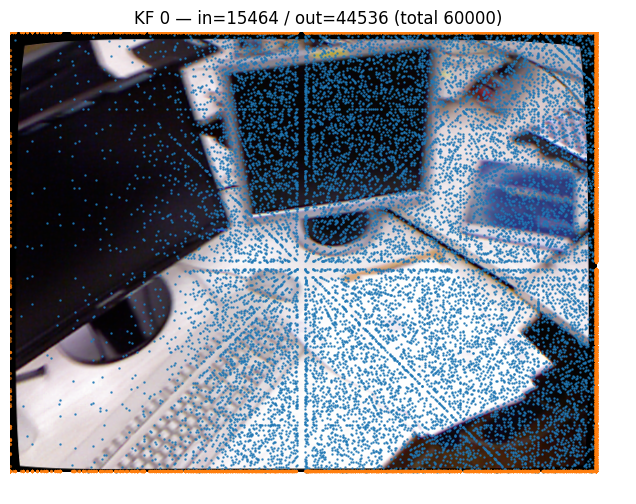

[KF   1] total= 60000  in_frame= 16685  out_frame= 43315  behind=   131  img=kf_1.png


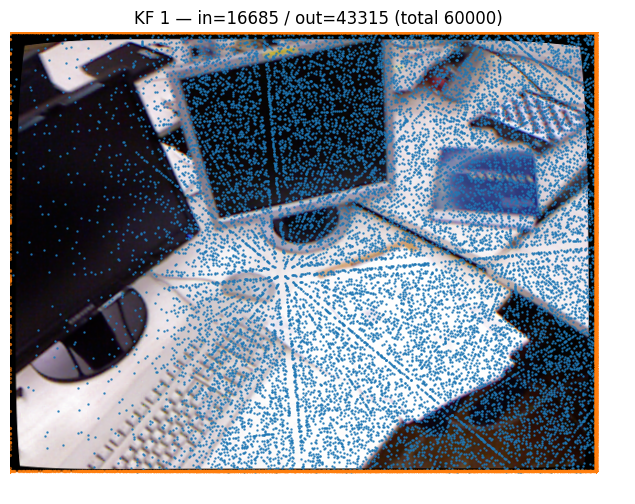

[ERR ] cannot read image: /home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/proj_debug/imgs/kf_90.png
[ERR ] cannot read image: /home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/proj_debug/imgs/kf_91.png


[ WARN:0@0.310] global loadsave.cpp:268 findDecoder imread_('/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/proj_debug/imgs/kf_90.png'): can't open/read file: check file path/integrity
[ WARN:0@0.310] global loadsave.cpp:268 findDecoder imread_('/home/dimitris/Photo-SLAM/results/tum_voxel/rgbd_dataset_freiburg1_desk/proj_debug/imgs/kf_91.png'): can't open/read file: check file path/integrity


In [1]:
import os, numpy as np, matplotlib.pyplot as plt
import cv2

BASE = "/home/dimitris/Photo-SLAM"
RUN  = "results/tum_voxel/rgbd_dataset_freiburg1_desk"
PROJ_DIR = os.path.join(BASE, RUN, "proj_debug")
KF_TXT   = os.path.join(PROJ_DIR, "keyframes_proj.txt")
VOX_NPY  = os.path.join(BASE, "debug_vox_centers.npy")

np.random.seed(0)

def load_kfs(path):
    kfs = []
    with open(path, "r") as f:
        for i, ln in enumerate(f):
            ln = ln.strip()
            if not ln: 
                continue
            parts = ln.split()
            if len(parts) < 24:
                print(f"[WARN] line {i} malformed ({len(parts)} tokens)")
                continue
            fid = int(parts[0])
            W, H = int(parts[1]), int(parts[2])
            fx, fy, cx, cy = map(float, parts[3:7])
            Tcw = np.array(list(map(float, parts[7:23])), dtype=np.float32).reshape(4,4)
            img_rel = parts[23]
            img_path = os.path.join(PROJ_DIR, img_rel)
            kfs.append(dict(fid=fid, W=W, H=H, fx=fx, fy=fy, cx=cx, cy=cy, Tcw=Tcw, img=img_path))
    # keep last per fid, then sort
    uniq = {d["fid"]: d for d in kfs}
    return [uniq[k] for k in sorted(uniq.keys())]

def project_points_uv(Tcw, fx, fy, cx, cy, Xw):
    """Return image-plane coords (u,v) for *all* points (no coloring)."""
    N  = Xw.shape[0]
    Xh = np.concatenate([Xw.astype(np.float32), np.ones((N,1), np.float32)], axis=1)   # (N,4)
    Xc = (Tcw @ Xh.T).T                                                                  # (N,4)
    x, y, z = Xc[:,0], Xc[:,1], Xc[:,2]
    # avoid div-by-zero; we won't color by z anyway
    z_safe = np.where(np.abs(z) < 1e-6, np.sign(z) * 1e-6 + (z == 0)*1e-6, z)
    u = fx * (x / z_safe) + cx
    v = fy * (y / z_safe) + cy
    return np.stack([u, v], axis=1), z

def clip_to_image_border(uv, W, H):
    u = np.clip(uv[:,0], 0, W-1)
    v = np.clip(uv[:,1], 0, H-1)
    return np.stack([u, v], axis=1)

# --- Load data ---
kfs = load_kfs(KF_TXT)
print(f"[INFO] Loaded {len(kfs)} keyframes from {KF_TXT}")
P   = np.load(VOX_NPY).astype(np.float32)
print(f"[INFO] Voxel centers: {P.shape}")

# Subsample for speed (adjust as you like)
M = P.shape[0]
S = min(M, 60_000)
Pviz = P if S == M else P[np.random.choice(M, S, replace=False)]
print(f"[INFO] Using {Pviz.shape[0]} / {M} points")

def visualize_kf_binary(kf, s_in=0.6, s_out=2.0, alpha_in=0.8, alpha_out=0.55):
    # read image
    img_bgr = cv2.imread(kf["img"])
    if img_bgr is None:
        print(f"[ERR ] cannot read image: {kf['img']}")
        return
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    uv, z = project_points_uv(kf["Tcw"], kf["fx"], kf["fy"], kf["cx"], kf["cy"], Pviz)

    # classify purely by whether the projected (u,v) lands inside the image
    in_w  = (uv[:,0] >= 0) & (uv[:,0] < W)
    in_h  = (uv[:,1] >= 0) & (uv[:,1] < H)
    in_img = in_w & in_h
    out_img = ~in_img

    # optional: track “behind camera” just for counts (not for coloring)
    behind = z <= 0

    # clip out-of-frame to draw on the border so we can see where they’d exit
    uv_clip = clip_to_image_border(uv, W, H)

    print(f"[KF {kf['fid']:>3}] total={len(uv):>6}  in_frame={in_img.sum():>6}  "
          f"out_frame={out_img.sum():>6}  behind={behind.sum():>6}  img={os.path.basename(kf['img'])}")

    plt.figure(figsize=(8,6))
    plt.imshow(img)

    # in-frame: solid points
    if in_img.any():
        plt.scatter(uv[in_img,0], uv[in_img,1], s=s_in, alpha=alpha_in)

    # out-of-frame: draw clipped positions as small x markers
    if out_img.any():
        plt.scatter(uv_clip[out_img,0], uv_clip[out_img,1], s=s_out, marker='x', alpha=alpha_out)

    plt.title(f"KF {kf['fid']} — in={in_img.sum()} / out={out_img.sum()} (total {len(uv)})")
    plt.axis('off')
    plt.show()

# Show the specific KFs you mentioned
wanted = [0, 1, 90, 91]
id2kf = {d["fid"]: d for d in kfs}
for fid in wanted:
    if fid in id2kf:
        visualize_kf_binary(id2kf[fid])
    else:
        print(f"[WARN] KF {fid} not found")
